### Section A: Output Prediction 

## A1.  K-Means by hand

(a) Predict the output of line 1 (labels_).  [1]

[0 0 0 1 1 1]

(b) Predict the output of line 2 (cluster_centers_).  [1]

[2. 11.]

(c) Predict the output of line 3 (inertia_) and show how you computed it.  [1]

4

(d) Trace the first two assign-and-update iterations to justify your answers. State the centres after each update.  

Centres: Iteration 1 → [1.0, 7.6]

In [1]:
import numpy as np
from sklearn.cluster import KMeans
 
X = np.array([[1], [2], [3], [10], [11], [12]])
init = np.array([[1.0], [2.0]])        # deliberately poor starting centres
 
km = KMeans(n_clusters=2, init=init, n_init=1).fit(X)

In [2]:
print(km.labels_) 

[0 0 0 1 1 1]


In [3]:
print(km.cluster_centers_.ravel())

[ 2. 11.]


In [4]:
print(km.inertia_)   

4.0


In [5]:
import numpy as np

X = np.array([1, 2, 3, 10, 11, 12])

# Initial centres
centers = np.array([1.0, 2.0])

# Iteration 1
labels = np.argmin(np.abs(X[:, None] - centers), axis=1)

centers[0] = X[labels == 0].mean()
centers[1] = X[labels == 1].mean()

print("Iteration 1 centres:", centers)

# Iteration 2
labels = np.argmin(np.abs(X[:, None] - centers), axis=1)

centers[0] = X[labels == 0].mean()
centers[1] = X[labels == 1].mean()

print("Iteration 2 centres:", centers)

Iteration 1 centres: [1.  7.6]
Iteration 2 centres: [ 2. 11.]


### A2.  PCA on correlated data 

Predict line 1.  

Expected Output: 1

(b) Predict line 2, showing the centring and projection working.


Expected Output: [3.35 1.12 1.12 3.35]

(c) Predict lines 3 and 4 and explain why line 4 prints that value. 


Expected Output:(4, 1)

(d) Why does the code apply np.abs before printing? What would a reviewer be worried about without it?


In [6]:
import numpy as np
from sklearn.decomposition import PCA
 
X = np.array([[1, 2], [2, 4], [3, 6], [4, 8]], dtype=float)
 
pca = PCA(n_components=1).fit(X)
Z = pca.transform(X)
 
print(pca.explained_variance_ratio_)       # line 1
print(np.abs(Z).ravel().round(2))          # line 2
print(Z.shape)                             # line 3
print(np.allclose(pca.inverse_transform(Z), X))   # line 4


[1.]
[3.35 1.12 1.12 3.35]
(4, 1)
True


(d) Why does the code apply np.abs before printing? What would a reviewer be worried about without it?


inverse_transform() converts the PCA data back from 1 dimension to the original 2-dimensional space.
Normally, reducing 2 dimensions to 1 could lose information.
But here the two features are perfectly correlated

## Section B: Code Refactoring 

In [8]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def customer_segmentation(
    file_path=r"C:\Users\hp\Desktop\Trivikram\phase 2\Module 4 Unsupervised Learning\cleaned_customer__churn _vikki.csv",
    features=("Annual_Income", "Spending_Score", "Age"),
    k_range=range(2, 6),
    random_state=42
):
    # Load dataset
    df = pd.read_csv(file_path)

    # Select features
    X = df[list(features)]

    # Standardize features using scikit-learn
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Find the best k using silhouette score
    scores = {}

    for k in k_range:
        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )
        labels = model.fit_predict(X_scaled)
        scores[k] = silhouette_score(X_scaled, labels)

    # Select k with the highest silhouette score
    best_k = max(scores, key=scores.get)

    # Final K-Means model
    kmeans = KMeans(
        n_clusters=best_k,
        random_state=random_state,
        n_init=10
    )
    df["cluster"] = kmeans.fit_predict(X_scaled)

    # Create cluster profile in a single step
    profile = df.groupby("cluster")[list(features)].mean()

    print("Best k:", best_k)
    print("Silhouette score:", scores[best_k])
    print("\nCluster Profile:")
    print(profile)

    return df, profile


# Run the segmentation
df_clustered, cluster_profile = customer_segmentation()

Best k: 5
Silhouette score: 0.2581618703576263

Cluster Profile:
         Annual_Income  Spending_Score        Age
cluster                                          
0         50336.956522       39.065217  28.130435
1         89056.521739       44.978261  34.521739
2         70603.703704       27.259259  46.777778
3         60038.888889       79.944444  32.277778
4         54297.674419       54.581395  42.093023


### Change Log — Latest Refactored Code


Removed duplication: Used a loop to test all k values from 2 to 5 instead of writing separate K-Means and silhouette-score code for each value.

Made it reusable: The file path, feature list, k-range, and random state are provided as function parameters, so the same code can be reused with other datasets.

Used scikit-learn tooling: Replaced manual scaling with StandardScaler() for proper and consistent feature standardization.

Made results reproducible: Set random_state=42 and n_init=10 in K-Means so the clustering results are consistent across runs.

Simplified profiling: Used a single groupby() operation to calculate the mean of all selected features for each cluster, instead of calculating each feature separately.

### B2. Dimensionality Reduction Helper

### Problems in the original code

1. **Data leakage:** the test mean and standard deviation are used for test scaling.
2. **Different scaling:** train and test data are not guaranteed to use the same scaling statistics.
3. **Inefficient:** PCA is fitted repeatedly inside a loop.
4. **Hard-coded:** the 90% variance target cannot be changed easily.
5. **Maintainability:** scaling and PCA are handled manually instead of using a pipeline.

In [10]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def reduce(train, test, variance_target=0.90):
    """Standardize training data, fit PCA, and transform train and test data."""

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=variance_target))
    ])

    train_reduced = pipeline.fit_transform(train)
    test_reduced = pipeline.transform(test)

    return train_reduced, test_reduced

train = np.array([
    [1, 2],
    [2, 4],
    [3, 6],
    [4, 8]
], dtype=float)

test = np.array([
    [5, 10],
    [6, 12]
], dtype=float)

train_reduced, test_reduced = reduce(
    train,
    test,
    variance_target=0.90
)

print("Reduced train shape:", train_reduced.shape)
print("Reduced test shape:", test_reduced.shape)

Reduced train shape: (4, 1)
Reduced test shape: (2, 1)


### B2 Change log

- Fit StandardScaler only on training data to avoid leakage.
- Use the same fitted preprocessing for the test data.
- Let PCA choose the smallest number of components for a configurable variance target.
- Removed the repeated PCA loop and used a clean pipeline.

# Section C – Scenario-Based Questions

### C1. Bank Customer Segmentation

### (a) Preprocessing

First, I would examine the data for missing values, unusual distributions, and extreme observations. Since a small percentage of customers have balances much higher than the median, I would reduce their influence using a log transformation or controlled winsorization. I would not remove them because high-value customers may be important to the bank. For the 8% missing credit-card spend values, I would use an appropriate imputation method such as the median instead of dropping those customers. The numerical variables should then be standardized so that variables with larger numerical scales do not dominate the clustering. Finally, preferred channel is categorical, so I would convert it into numerical form using one-hot encoding.

### (b) Choosing the Number of Segments

Although Marketing has requested five segments, I would test whether five actually produces meaningful clusters. I would compare several values of **k** using quantitative measures such as the **silhouette score** and **Davies-Bouldin index**. A good solution should have a high silhouette score and a low Davies-Bouldin score. In addition, I would consider a business criterion: whether each segment is sufficiently large, easy to describe, and supports a different marketing strategy. If five segments provide useful and actionable customer groups, I would retain five even if another value of k performs slightly better statistically.

### (c) Stability and Usefulness

I would test stability by repeating the clustering with different random initializations or different samples of customers and checking whether similar groups are produced. I would then examine the characteristics of each segment, such as balance, transaction activity, products, tenure, and spending. The final segments should be stable, clearly different from one another, and large enough to support practical marketing actions.

## C2. Clustering Support-Ticket Embeddings

### (a) Critique

I would not use t-SNE to reduce the embeddings to 2D and then perform K-Means on those 2D coordinates.

1. **t-SNE is primarily designed for visualization**, not as a reliable preprocessing step for clustering.
2. Reducing 768 dimensions directly to 2 dimensions can **lose important information** about the original ticket relationships.
3. t-SNE can change its output depending on parameters and random initialization, so the resulting clusters may not be stable.
4. K-Means on the 2D representation may create groups that are caused by the visualization rather than genuine similarities in the original embeddings.
5. Calling these groups definite “issue themes” without further validation could give leadership misleading conclusions.

### (b) Improved Pipeline

I would use the following approach:

**768-dimensional embeddings → Normalize/check data → PCA for dimensionality reduction → Clustering → Cluster validation**

If necessary, PCA can reduce the embeddings to a reasonable number of dimensions while retaining most of the important variance. K-Means or another suitable clustering algorithm can then be applied to this reduced representation.

**t-SNE or UMAP should mainly be used for visualization**, allowing us to plot the discovered clusters in 2D and inspect their separation. They should not be treated as the primary source for creating the clusters.

### (c) Validation

I would evaluate the clusters using measures such as **silhouette score** and **Davies-Bouldin index**, and check whether the clusters remain similar with different random seeds or samples. Most importantly, I would manually inspect representative support tickets from each cluster and compare their content. If tickets within a cluster consistently describe similar problems, the cluster is more likely to represent a genuine support theme rather than a dimensionality-reduction artefact.

# Section D – Edge Cases

### D1(a). Duplicate points with too many clusters

### Prediction

There are only **2 unique points**, but `n_clusters=3`. I expect K-Means to run but produce a `ConvergenceWarning` saying that the number of distinct clusters is smaller than the requested number of clusters.

In [12]:
import warnings
X = np.array([[1, 1], [1, 1], [2, 2], [2, 2]], dtype=float)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)

print("Labels:", model.labels_)
for w in caught:
    print("Warning:", w.message)

unique_points = np.unique(X, axis=0)
print("Unique points:", len(unique_points))
print("Requested clusters:", 3)

if len(unique_points) < 3:
    print("Programmatic check: too few unique points for the requested number of clusters.")


Labels: [1 1 0 0]
Unique points: 2
Requested clusters: 3
Programmatic check: too few unique points for the requested number of clusters.


### Explanation

The warning happens because the data contains only two distinct locations: `[1,1]` and `[2,2]`. K-Means cannot create three genuinely different groups from only two unique points.

A production pipeline should compare the number of unique rows with the requested number of clusters before fitting.

### D1(b). Zero-variance feature

### Prediction

The second column is constant, so its standard deviation is zero. The manual z-score divides by zero and produces `NaN` values. `StandardScaler` handles the constant column safely and converts it to zeros.

In [14]:
import warnings
X = np.array([[1, 5], [2, 5], [3, 5]], dtype=float)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    manual = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

print("Manual z-score:")
print(manual)

for w in caught:
    print("Warning:", w.message)

sk = StandardScaler().fit_transform(X)

print("\nStandardScaler result:")
print(sk)

print("\nK-Means with StandardScaler:")
print(KMeans(n_clusters=2, n_init=10, random_state=0).fit(sk).labels_)


Manual z-score:
[[-1. nan]
 [ 0. nan]
 [ 1. nan]]

StandardScaler result:
[[-1.22474487  0.        ]
 [ 0.          0.        ]
 [ 1.22474487  0.        ]]

K-Means with StandardScaler:
[0 0 1]


### Explanation
The manual z-score calculation fails because the second feature has no variation, making its standard deviation equal to zero. Dividing by zero results in NaN values, which K-Means cannot process.
StandardScaler handles this situation safely by giving the constant feature a scaled value of 0 for every row. Therefore, K-Means can still perform clustering using the remaining varying features.
For a production pipeline, it is also a good practice to detect and remove constant features before clustering.

### D1(c). Non-spherical clusters

### Prediction

K-Means should perform worse because moon-shaped clusters are not spherical. DBSCAN should perform much better because it uses density and can follow curved cluster shapes.

In [15]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

X, y_true = make_moons(300, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=0)
km_labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=0.2)
db_labels = dbscan.fit_predict(X)

scores = {
    "K-Means": adjusted_rand_score(y_true, km_labels),
    "DBSCAN": adjusted_rand_score(y_true, db_labels)
}

for algorithm, score in scores.items():
    print(f"{algorithm} ARI: {score:.4f}")

K-Means ARI: 0.2408
DBSCAN ARI: 1.0000


### Explanation
The scores are approximately:

K-Means ARI = 0.2408

DBSCAN ARI  = 1.0000

K-Means does not perform well here because it assigns data points based on their distance from cluster centers, which is more suitable for compact, round-shaped groups. The moon-shaped data has a curved structure, so K-Means cannot separate the groups correctly.
DBSCAN gives a perfect score because it identifies groups based on the density and connectivity of nearby points. This allows it to capture the curved structure of the two moon-shaped clusters much more effectively.

### D1(d). Production Checks
I would include these automatic checks:
1. Silhouette score: Identify clustering results with a very low score, indicating poor separation between clusters.
2. Cluster-size check: Flag clusters that contain very few observations, as they may not be reliable.
3. Stability check: Run the clustering with different random seeds and verify that the resulting clusters remain similar.

### D2(a). More PCA Components Than the Data Allows

Prediction

The dataset contains 5 samples and 20 features. The maximum number of PCA components is determined by:

min(n_samples, n_features)

= min(5, 20)

= 5

Since the code requests 10 components, which is greater than the allowed maximum of 5, PCA should raise a ValueError.

In [16]:
X = np.random.RandomState(0).rand(5, 20)

try:
    PCA(n_components=10).fit(X)
except ValueError as e:
    print("Error:", e)

print("Maximum number of components:", min(X.shape[0], X.shape[1]))

Error: n_components=10 must be between 0 and min(n_samples, n_features)=5 with svd_solver='full'
Maximum number of components: 5


### Explanation

The number of PCA components cannot be greater than either the number of samples or the number of features. Therefore, PCA takes the smaller of these two values as the limit. For this dataset, the maximum possible number of components is 5.

### D2(b). Missing Values
Prediction

PCA cannot process NaN values directly, so the given code is expected to produce a ValueError.
To handle this safely, the imputer should be fitted using only the training data. The same fitted imputer is then applied to both the training and test sets, avoiding data leakage from the test data.

In [17]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

X = np.random.RandomState(0).rand(10, 3)
X[0, 0] = np.nan

try:
    pca = PCA(n_components=2)
    pca.fit(X)
except ValueError as error:
    print("Error:", error)

X_train = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5]
], dtype=float)

X_test = np.array([
    [4, np.nan, 6]
], dtype=float)

fill_missing = SimpleImputer(strategy="median")

X_train = fill_missing.fit_transform(X_train)
X_test = fill_missing.transform(X_test)

model = PCA(n_components=2)

train_result = model.fit_transform(X_train)
test_result = model.transform(X_test)

print("Training PCA shape:", train_result.shape)
print("Test PCA shape:", test_result.shape)

Error: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
Training PCA shape: (3, 2)
Test PCA shape: (1, 2)


### Explanation

The median is calculated using only the training dataset. After that, the already-fitted imputer is used to fill missing values in the test dataset. This keeps test-set information separate and prevents data leakage.

### D2(c). Degenerate Data

Prediction

Since all the values are identical, the dataset has zero variance. Therefore, I expect PCA's explained_variance_ratio_ to return NaN values, because the total variance is zero.

In [18]:
X = np.ones((6, 3))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    ratio = PCA(n_components=2).fit(X).explained_variance_ratio_

print("Explained variance ratio:", ratio)

for w in caught:
    print("Warning:", w.message)

if np.all(np.var(X, axis=0) == 0):
    print("Guard check: all features have zero variance.")

Explained variance ratio: [nan nan]
Guard check: all features have zero variance.


### Explanation

Since all the features remain constant, there is no variation available for PCA to capture. Therefore, the explained variance ratio becomes NaN. In a production pipeline, I would check for zero-variance features before applying PCA and either remove those features or stop the process with a clear warning.

### D2(d). Features on Very Different Scales

Prediction

The second feature has a scale that is about 1000 times larger than the first feature. Therefore, without standardization, PCA is expected to assign nearly all of the variance to the second feature.
After applying standardization, both features are brought to a comparable scale, so their contributions to the principal components should become much more balanced.

In [19]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)

A = np.column_stack([
    rng.normal(0, 1, 200),
    rng.normal(0, 1, 200) * 1000
])

raw = PCA().fit(A)
scaled = PCA().fit(StandardScaler().fit_transform(A))

print("Without scaling:", raw.explained_variance_ratio_)
print("With StandardScaler:", scaled.explained_variance_ratio_)

Without scaling: [9.99998834e-01 1.16589485e-06]
With StandardScaler: [0.53780576 0.46219424]


### Explanation

The results are approximately:

Without scaling: [0.9999988 0.0000012]

With scaling:    [0.5378 0.4622]


Without standardization, the much larger numerical scale of feature 2 causes it to dominate the PCA result.

After standardization, the two features are brought to a similar scale, so their contributions are much more balanced. Therefore, when features have very different units or ranges and those differences should not influence their importance, standardization should generally be applied before PCA.

# Section E – End-to-End Customer Segmentation

### Generate the assignment dataset

In [21]:
def make_customers(n=1500, seed=42):
    rng = np.random.default_rng(seed)
    seg = rng.choice(4, size=n, p=[0.40, 0.30, 0.20, 0.10])

    # (monthly_spend, orders_per_month, return_rate)
    spec = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = np.array([
        max(5, rng.normal(spec[s][0], spec[s][0] * 0.25))
        for s in seg
    ])

    orders = np.array([
        max(1, rng.poisson(spec[s][1]))
        for s in seg
    ])

    ret = np.array([
        min(1, max(0, rng.normal(spec[s][2], 0.05)))
        for s in seg
    ])

    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": spend.round(2),
        "orders_per_month": orders,
        "return_rate": ret.round(3),
        "tenure_months": rng.integers(1, 60, n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            n,
            p=[0.45, 0.40, 0.15]
        )
    })

    df.loc[
        rng.choice(n, 60, replace=False),
        "monthly_spend"
    ] = np.nan

    return df


df = make_customers()

print("Shape:", df.shape)
print("Missing monthly_spend:", df["monthly_spend"].isna().sum())
display(df.head())


Shape: (1500, 6)
Missing monthly_spend: 60


,customer_id,monthly_spend,orders_per_month,return_rate,tenure_months,preferred_channel
0,1,3101.85,32,0.129,47,app
1,2,736.96,17,0.121,26,app
2,3,1966.40,26,0.031,4,store
3,4,1003.43,15,0.107,22,store
4,5,374.14,11,0.249,6,app


## E1. Problem framing and feature design

The main objective is to divide customers into meaningful groups so that the company can design targeted retention strategies and personalized marketing offers.

I would include `monthly_spend`, `orders_per_month`, `return_rate`, `tenure_months`, and `preferred_channel` as the main customer features.

I would remove `customer_id` because it is simply an identifier and does not provide useful information about customer behaviour.

The missing values in `monthly_spend` can be handled using median imputation. The median is suitable because it is less influenced by unusually high or low spending values. The numerical variables should then be standardized so that features with larger numerical ranges do not dominate the clustering.

Since `preferred_channel` contains categories such as web, app, and store, I would convert it into numerical form using one-hot encoding.

Finally, I would examine the distribution of `monthly_spend` and check for extreme values because very high spending values could have a significant influence on K-Means clustering.

### E2. Pipeline implementation

The pipeline below handles:

- Imputation

- Scaling

- Categorical encoding

- PCA

- K-Means


In [24]:
RANDOM_STATE = 42

num_cols = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months"
]

cat_cols = ["preferred_channel"]

all_features = num_cols + cat_cols

num_pipe = Pipeline([
    ("missing", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

cat_pipe = Pipeline([
    ("missing", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

processor = ColumnTransformer([
    ("numbers", num_pipe, num_cols),
    ("categories", cat_pipe, cat_cols)
])


def make_pipeline(k):
    return Pipeline([
        ("preprocess", processor),
        ("pca", PCA(n_components=0.90)),
        ("kmeans", KMeans(
            n_clusters=k,
            n_init=20,
            random_state=RANDOM_STATE
        ))
    ])


model = make_pipeline(3)

model.fit(df[all_features])

df["cluster"] = model.predict(df[all_features])

print("Pipeline completed.")
display(df.head())

Pipeline completed.


,customer_id,monthly_spend,orders_per_month,return_rate,tenure_months,preferred_channel,cluster
0,1,3101.85,32,0.129,47,app,0
1,2,736.96,17,0.121,26,app,0
2,3,1966.40,26,0.031,4,store,0
3,4,1003.43,15,0.107,22,store,0
4,5,374.14,11,0.249,6,app,1


### E3. Model Selection and Validation

I would test different cluster values from k=2 through k=6 and evaluate them using two measures:

- Silhouette score: A larger value indicates better-separated and more compact clusters.

- Davies-Bouldin score: A smaller value indicates better clustering quality.
In addition, I would run the clustering with multiple random seeds to check whether the customer assignments remain consistent.

If the two evaluation measures suggest different values of k, I would consider both results rather than relying on only one metric. The final number of clusters would be selected based on the overall evidence, stability, and whether the resulting segments are simple and useful for the business.

In [26]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_STATE = 42

features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months",
    "preferred_channel"
]

numeric_features = [
    "monthly_spend",
    "orders_per_month",
    "return_rate",
    "tenure_months"
]

categorical_features = ["preferred_channel"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

preprocess_pca = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=0.90))
])

X_pca = preprocess_pca.fit_transform(df[features])

results = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette_score": silhouette_score(X_pca, labels),
        "davies_bouldin_score": davies_bouldin_score(X_pca, labels)
    })

selection_df = pd.DataFrame(results)

display(selection_df.round(4))

best_silhouette_k = selection_df.loc[
    selection_df["silhouette_score"].idxmax(), "k"
]

best_db_k = selection_df.loc[
    selection_df["davies_bouldin_score"].idxmin(), "k"
]

print("Best k by silhouette:", best_silhouette_k)
print("Best k by Davies-Bouldin:", best_db_k)

,k,silhouette_score,davies_bouldin_score
0,2,0.3127,1.2474
1,3,0.3296,1.1519
2,4,0.3161,1.2385
3,5,0.3053,1.1370
4,6,0.3099,1.0823


Best k by silhouette: 3
Best k by Davies-Bouldin: 6


### Final Choice

For this dataset, I would select k = 3 because it provides the best silhouette score among the tested values. Although the Davies-Bouldin score may indicate a different value, I would consider both measures before making the final decision.

A three-cluster solution is also easier to interpret and communicate to the marketing team. Since there is no fixed correct value of k, the final selection should be supported by the evaluation results and business usefulness.
I would also test the clustering with different random seeds to confirm that the three segments are stable and consistent.

In [30]:
final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("pca", PCA(n_components=0.90)),
    ("clustering", KMeans(
        n_clusters=3,
        n_init=20,
        random_state=42
    ))
])

profile_data = df.copy()

profile_data["cluster"] = final_model.fit_predict(
    profile_data[features]
)

profile = (
    profile_data
    .groupby("cluster")[numeric_features]
    .mean()
    .round(2)
)

profile["customer_count"] = (
    profile_data.groupby("cluster").size()
)

display(profile)

print("Preferred channel distribution:")

channel_distribution = pd.crosstab(
    profile_data["cluster"],
    profile_data["preferred_channel"],
    normalize="index"
).round(2)

display(channel_distribution)

,monthly_spend,orders_per_month,return_rate,tenure_months,customer_count
cluster,,,,,
0,1598.01,20.36,0.08,28.78,732
1,334.28,6.31,0.29,30.45,632
2,6057.59,11.62,0.03,33.27,136


Preferred channel distribution:


preferred_channel,app,store,web
cluster,,,
0,0.38,0.14,0.48
1,0.42,0.14,0.44
2,0.40,0.14,0.46


### Human-Readable Segment Interpretation

Segment 0 – Consistent High-Value Customers
These customers show fairly strong spending along with frequent purchases.

Action: Provide loyalty benefits, personalized product suggestions, and special promotional offers.

Segment 1 – Low-Spending Frequent Returners

This group has comparatively lower spending and a higher tendency to return products.

Action: Analyze the reasons for returns, improve product matching, and provide suitable targeted discounts.

Segment 2 – Premium Customers

This is a smaller segment characterized by very high spending and relatively few returns.

Action: Offer VIP benefits, premium customer service, early access to new products, and exclusive promotions.

The cluster numbers themselves do not represent any particular business category because K-Means assigns them arbitrarily. The actual cluster statistics should be examined before giving each segment a meaningful name.

### E5. Productionisation and Extension

Once the model is deployed, I would regularly track changes in important customer features such as monthly spending, number of orders, and return rate. I would also observe the number of customers assigned to each cluster. Significant changes in these patterns could indicate customer behaviour drift.
Retraining would be considered if there is substantial data drift, clustering performance decreases, or there are major changes in the customer base or business strategy. The segments should also be reviewed regularly with the marketing team.

For adding 384-dimensional product-review embeddings, I would process the embeddings separately and use dimensionality reduction such as PCA before combining them with the existing customer features. This helps prevent the large number of embedding features from overpowering the behavioural variables.
For the 2-D visualization, I would use PCA to project the data into two dimensions and display the clusters using different labels or colours. This can help show the approximate separation and structure of the segments, but it cannot confirm that the clusters are genuinely meaningful. It is only a simplified representation of the original feature space.

### Optional 2-D visualization of the final segments

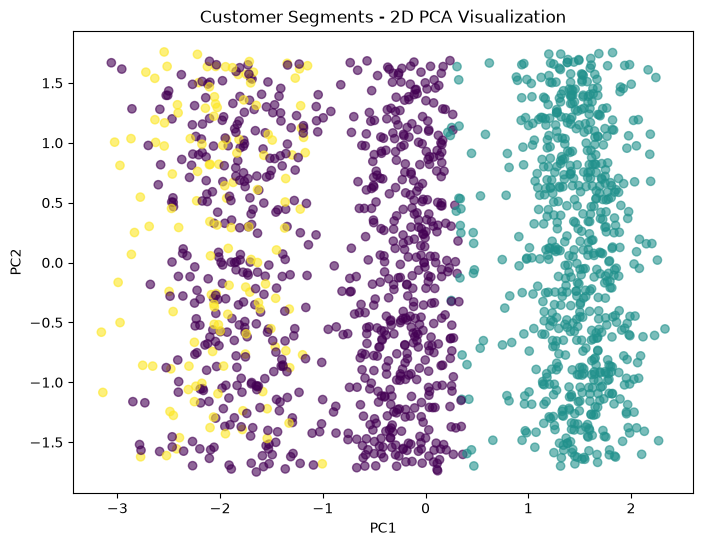

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df_profile = df.copy()

df_profile["cluster"] = final_model.predict(
    df_profile[features]
)

processed_data = preprocessor.fit_transform(
    df_profile[features]
)

pca_2d = PCA(n_components=2)

coordinates = pca_2d.fit_transform(processed_data)

plt.figure(figsize=(8, 6))

plt.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    c=df_profile["cluster"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments - 2D PCA Visualization")
plt.show()

### Generate_Customers

In [34]:
import numpy as np
import pandas as pd

def make_customers(n=1500, seed=42):
    rng = np.random.default_rng(seed)

    groups = rng.choice(
        4,
        size=n,
        p=[0.40, 0.30, 0.20, 0.10]
    )

    settings = {
        0: (300, 6, 0.30),
        1: (900, 14, 0.10),
        2: (2500, 30, 0.05),
        3: (6000, 12, 0.02)
    }

    spend = []
    orders = []
    returns = []

    for group in groups:
        mean_spend, mean_orders, mean_return = settings[group]

        spend.append(
            max(5, rng.normal(mean_spend, mean_spend * 0.25))
        )

        orders.append(
            max(1, rng.poisson(mean_orders))
        )

        returns.append(
            np.clip(rng.normal(mean_return, 0.05), 0, 1)
        )

    customers = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "monthly_spend": np.round(spend, 2),
        "orders_per_month": orders,
        "return_rate": np.round(returns, 3),
        "tenure_months": rng.integers(1, 60, size=n),
        "preferred_channel": rng.choice(
            ["web", "app", "store"],
            size=n,
            p=[0.45, 0.40, 0.15]
        )
    })

    missing = rng.choice(n, size=60, replace=False)
    customers.loc[missing, "monthly_spend"] = np.nan

    return customers


df = make_customers()

print("Dataset shape:", df.shape)
print("Missing monthly spend:", df["monthly_spend"].isna().sum())
display(df.head())

Dataset shape: (1500, 6)
Missing monthly spend: 60


,customer_id,monthly_spend,orders_per_month,return_rate,tenure_months,preferred_channel
0,1,3101.85,44,0.073,14,web
1,2,1122.42,14,0.032,23,app
2,3,1608.04,34,0.106,26,app
3,4,896.98,11,0.027,16,app
4,5,270.70,7,0.231,38,app
